# Rail Operations Forecaster
## Notebook 06 — Scenario Analysis

**Business Objective:**  
Evaluate how predicted next-day terminal dwell changes under stressed operating conditions such as inbound volume surges, crew shortages, and locomotive availability declines. This notebook uses the tuned Phase 1 LightGBM model as a what-if engine for operational decision support.

> **Audience:** This notebook is written for analysts and operations leaders who want to understand how sensitive terminal dwell may be to realistic operating stress scenarios.

## Scenario analysis approach

This notebook does not retrain a new model or change the forecasting target. Instead, it reuses the tuned Phase 1 model and applies controlled changes to selected input features in order to simulate what-if operating conditions.

The goal is to estimate how the model expects next-day terminal dwell to respond if workload increases or resource availability declines. This helps translate the predictive model into a practical decision-support tool rather than only a historical forecasting exercise.

In [44]:
from pathlib import Path

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("Imports OK")

Imports OK


## Load and prepare the Phase 1 dataset

This notebook uses the same finalized Phase 1 dataset, feature set, and train/test split as the earlier notebooks. Keeping the scenario analysis aligned with the standardized Phase 1 setup ensures that scenario outputs remain consistent with the published baseline, tuning, and error-analysis results.

In [45]:
project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "synthetic" / "phase1_terminal_dwell.csv"

df = pd.read_csv(data_path, parse_dates=["date"])
df.columns = df.columns.str.strip()
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)

print("Data path:", data_path)
print("Shape:", df.shape)

df.head()

Data path: /home/jorge/projects/rail-ops-forecaster/data/synthetic/phase1_terminal_dwell.csv
Shape: (8760, 13)


,date,terminal_id,terminal_name,region,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,target_dwell_hours
0,2022-01-01,T01,Barstow,West,13,304,532,59.100,13,92.300,1,1,19.700
1,2022-01-02,T01,Barstow,West,11,223,461,51.200,11,95.300,1,1,19.500
2,2022-01-03,T01,Barstow,West,10,219,448,49.800,18,85.700,0,1,20.000
3,2022-01-04,T01,Barstow,West,7,138,350,38.900,14,88.500,0,1,20.400
4,2022-01-05,T01,Barstow,West,9,175,361,40.100,17,90.500,0,1,20.700


In [46]:
target_col = "target_dwell_hours"

feature_cols = [
    "terminal_id",
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

split_date = "2024-07-01"

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train = df.loc[train_mask, feature_cols].copy()
X_test = df.loc[test_mask, feature_cols].copy()
y_train = df.loc[train_mask, target_col].copy()
y_test = df.loc[test_mask, target_col].copy()

X_train["terminal_id"] = X_train["terminal_id"].astype("category")
X_test["terminal_id"] = X_test["terminal_id"].astype("category")

print("Number of features:", len(feature_cols))
print("Target column:", target_col)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train date range:", df.loc[train_mask, "date"].min(), "to", df.loc[train_mask, "date"].max())
print("Test date range:", df.loc[test_mask, "date"].min(), "to", df.loc[test_mask, "date"].max())

Number of features: 9
Target column: target_dwell_hours
Train shape: (7296, 9)
Test shape: (1464, 9)
Train date range: 2022-01-01 00:00:00 to 2024-06-30 00:00:00
Test date range: 2024-07-01 00:00:00 to 2024-12-30 00:00:00


In [47]:
# From Notebook 04 grid search
best_params = {
    "n_estimators": 200,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_child_samples": 20
}

tuned_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    **best_params
)

tuned_model.fit(
    X_train,
    y_train,
    categorical_feature=["terminal_id"]
)

print("Tuned model rebuilt successfully.")
print(type(tuned_model))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1066
[LightGBM] [Info] Number of data points in the train set: 7296, number of used features: 9
[LightGBM] [Info] Start training from score 19.060458
Tuned model rebuilt successfully.
<class 'lightgbm.sklearn.LGBMRegressor'>


## Build the baseline scenario table

The test set is used as the base population for scenario analysis. This provides a realistic set of terminal-day operating conditions that can be modified under controlled stress assumptions.

The baseline prediction is first generated for each observation. Later sections apply scenario changes to the same rows so the predicted effect of each stressor can be measured directly.

In [48]:
scenario_base = X_test.copy()
scenario_base["date"] = df.loc[test_mask, "date"].values
scenario_base["actual_dwell"] = y_test.values
scenario_base["baseline_predicted_dwell"] = tuned_model.predict(X_test)

scenario_base.head()

,terminal_id,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,date,actual_dwell,baseline_predicted_dwell
912,T01,6,125,90,10.000,22,82.600,0,7,2024-07-01,18.200,21.175
913,T01,14,340,226,25.100,22,87.000,0,7,2024-07-02,16.500,20.235
914,T01,12,282,109,12.100,20,89.800,0,7,2024-07-03,20.400,20.414
915,T01,12,224,90,10.000,15,88.800,0,7,2024-07-04,17.700,20.556
916,T01,12,233,90,10.000,15,93.900,0,7,2024-07-05,18.400,20.759


## Define scenario stress functions

Four stress scenarios are evaluated:

1. **Inbound surge** — inbound car count increases by 10%
2. **Crew shortage** — crew starts available decline by 15%
3. **Locomotive shortage** — locomotive availability declines by 10 percentage points
4. **Combined stress** — all three stressors are applied together

These are simple scenario assumptions, not claims about exact real-world magnitudes. Their purpose is to test directional sensitivity and show how the tuned model responds when workload rises or resource availability falls.

> **Important note:** These scenarios perturb selected features while holding correlated variables such as `cars_on_hand` and `yard_occupancy_pct` constant. This can create input combinations that are less realistic than the historical patterns the model was trained on. The interpretation section discusses the implications of this limitation.

In [49]:
def apply_inbound_surge(df_in):
    df_out = df_in.copy()
    df_out["inbound_car_count"] = df_out["inbound_car_count"] * 1.10
    return df_out

def apply_crew_shortage(df_in):
    df_out = df_in.copy()
    df_out["crew_starts_available"] = df_out["crew_starts_available"] * 0.85
    return df_out

def apply_locomotive_shortage(df_in):
    df_out = df_in.copy()
    df_out["locomotive_availability_pct"] = df_out["locomotive_availability_pct"] - 10
    df_out["locomotive_availability_pct"] = df_out["locomotive_availability_pct"].clip(lower=0)
    return df_out

def apply_combined_stress(df_in):
    df_out = df_in.copy()
    df_out["inbound_car_count"] = df_out["inbound_car_count"] * 1.10
    df_out["crew_starts_available"] = df_out["crew_starts_available"] * 0.85
    df_out["locomotive_availability_pct"] = (df_out["locomotive_availability_pct"] - 10).clip(lower=0)
    return df_out

In [50]:
def apply_operationally_linked_stress(df_in):
    df_out = df_in.copy()
    df_out["inbound_car_count"] = df_out["inbound_car_count"] * 1.10
    df_out["cars_on_hand"] = df_out["cars_on_hand"] * 1.08
    df_out["yard_occupancy_pct"] = (df_out["yard_occupancy_pct"] + 5).clip(upper=100)
    df_out["crew_starts_available"] = df_out["crew_starts_available"] * 0.90
    df_out["locomotive_availability_pct"] = (df_out["locomotive_availability_pct"] - 5).clip(lower=0)
    return df_out

## Score each scenario

Each scenario is applied to the same base test rows. The tuned model then generates a predicted dwell value under each stressed condition. This creates a comparable scenario table where only the selected stress inputs differ across rows.

In [51]:
scenario_results = []

scenario_dict = {
    "Baseline": X_test.copy(),
    "Inbound surge (+10% cars)": apply_inbound_surge(X_test),
    "Crew shortage (-15% crew)": apply_crew_shortage(X_test),
    "Locomotive shortage (-10 pts loco avail)": apply_locomotive_shortage(X_test),
    "Combined stress": apply_combined_stress(X_test),
    "Operationally linked stress": apply_operationally_linked_stress(X_test),
}

for scenario_name, scenario_X in scenario_dict.items():
    scenario_X = scenario_X.copy()
    scenario_X["terminal_id"] = scenario_X["terminal_id"].astype("category")

    preds = tuned_model.predict(scenario_X)

    scenario_results.append(
        pd.DataFrame({
            "date": df.loc[test_mask, "date"].values,
            "terminal_id": df.loc[test_mask, "terminal_id"].values,
            "scenario": scenario_name,
            "predicted_dwell": preds
        })
    )

scenario_results_df = pd.concat(scenario_results, ignore_index=True)

print("Scenario scoring complete.")
scenario_results_df.head()

Scenario scoring complete.


,date,terminal_id,scenario,predicted_dwell
0,2024-07-01,T01,Baseline,21.175
1,2024-07-02,T01,Baseline,20.235
2,2024-07-03,T01,Baseline,20.414
3,2024-07-04,T01,Baseline,20.556
4,2024-07-05,T01,Baseline,20.759


## Scenario-level summary

This section summarizes predicted dwell across the full test population under each scenario. The main question is whether the model responds directionally as expected when workload rises or resource capacity declines.

In [52]:
scenario_summary = (
    scenario_results_df
    .groupby("scenario")["predicted_dwell"]
    .agg(["mean", "median", "max"])
    .reset_index()
    .rename(columns={
        "mean": "avg_predicted_dwell",
        "median": "median_predicted_dwell",
        "max": "max_predicted_dwell"
    })
)

baseline_mean = scenario_summary.loc[
    scenario_summary["scenario"] == "Baseline",
    "avg_predicted_dwell"
].iloc[0]

scenario_summary["avg_change_vs_baseline"] = (
    scenario_summary["avg_predicted_dwell"] - baseline_mean
)

scenario_summary["pct_change_vs_baseline"] = (
    scenario_summary["avg_change_vs_baseline"] / baseline_mean * 100
).round(2)

scenario_summary = scenario_summary.sort_values("avg_predicted_dwell", ascending=False).reset_index(drop=True)
scenario_summary

,scenario,avg_predicted_dwell,median_predicted_dwell,max_predicted_dwell,avg_change_vs_baseline,pct_change_vs_baseline
0,Operationally linked stress,19.365,19.265,25.255,0.018,0.090
1,Crew shortage (-15% crew),19.353,19.201,25.191,0.006,0.030
2,Baseline,19.347,19.180,25.173,0.000,0.000
3,Locomotive shortage (-10 pts loco avail),19.299,19.258,25.566,-0.048,-0.250
4,Inbound surge (+10% cars),19.292,19.049,25.065,-0.055,-0.280
5,Combined stress,19.257,19.257,25.265,-0.090,-0.460


## Threshold-breach view under scenarios

To connect the scenario analysis back to the project's operational success criteria, this section measures how often predicted dwell exceeds a practical threshold. For illustration, a **24-hour dwell threshold** is used as a simple congestion-warning cutoff.

This does not replace full business validation, but it helps show whether stressed scenarios materially increase the share of terminal-days that would be flagged for operational attention.

In [53]:
dwell_threshold = 24.0

threshold_summary = (
    scenario_results_df
    .assign(threshold_breach=lambda x: x["predicted_dwell"] >= dwell_threshold)
    .groupby("scenario")
    .agg(
        breach_count=("threshold_breach", "sum"),
        total_obs=("threshold_breach", "count")
    )
    .reset_index()
)

threshold_summary["breach_rate_pct"] = (
    threshold_summary["breach_count"] / threshold_summary["total_obs"] * 100
).round(2)

threshold_summary = threshold_summary.sort_values("breach_rate_pct", ascending=False).reset_index(drop=True)
threshold_summary

,scenario,breach_count,total_obs,breach_rate_pct
0,Operationally linked stress,58,1464,3.960
1,Combined stress,45,1464,3.070
2,Locomotive shortage (-10 pts loco avail),44,1464,3.010
3,Crew shortage (-15% crew),42,1464,2.870
4,Baseline,36,1464,2.460
5,Inbound surge (+10% cars),25,1464,1.710


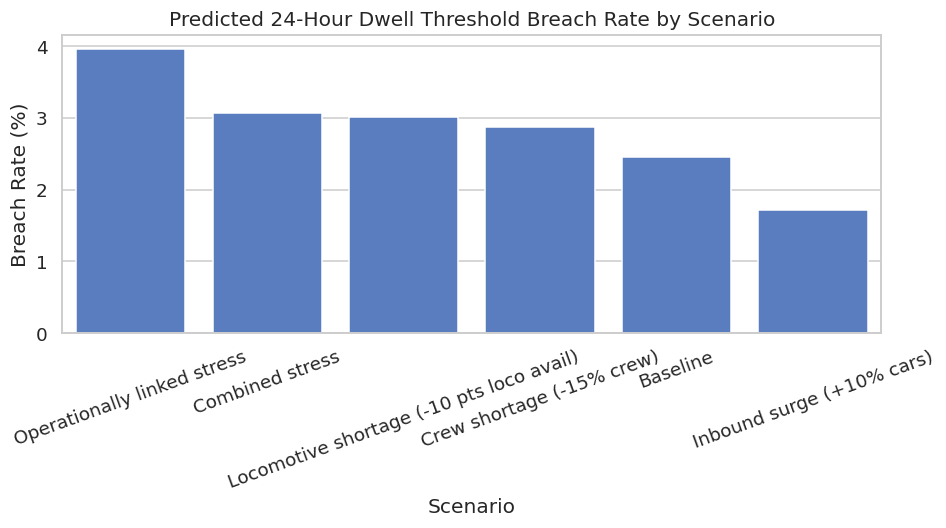

In [54]:
plt.figure(figsize=(9, 5))
sns.barplot(data=threshold_summary, x="scenario", y="breach_rate_pct")
plt.title("Predicted 24-Hour Dwell Threshold Breach Rate by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Breach Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Terminal-level sensitivity analysis

Average scenario effects can hide important differences across terminals. This section compares how much predicted dwell changes by terminal under each stress condition. The goal is to identify which terminals appear most sensitive to workload surges or resource shortages.

In [55]:
terminal_scenario_summary = (
    scenario_results_df
    .groupby(["terminal_id", "scenario"])["predicted_dwell"]
    .mean()
    .reset_index()
)

terminal_pivot = terminal_scenario_summary.pivot(
    index="terminal_id",
    columns="scenario",
    values="predicted_dwell"
).reset_index()

for col in terminal_pivot.columns:
    if col not in ["terminal_id", "Baseline"]:
        terminal_pivot[f"{col}_delta"] = terminal_pivot[col] - terminal_pivot["Baseline"]

terminal_pivot

scenario,terminal_id,Baseline,Combined stress,Crew shortage (-15% crew),Inbound surge (+10% cars),Locomotive shortage (-10 pts loco avail),Operationally linked stress,Combined stress_delta,Crew shortage (-15% crew)_delta,Inbound surge (+10% cars)_delta,Locomotive shortage (-10 pts loco avail)_delta,Operationally linked stress_delta
0,T01,20.745,20.483,20.770,20.692,20.498,20.659,-0.262,0.025,-0.053,-0.247,-0.086
1,T02,18.570,18.324,18.570,18.536,18.350,18.434,-0.246,0.000,-0.034,-0.220,-0.136
2,T03,22.202,22.000,22.231,22.156,22.015,22.071,-0.201,0.029,-0.046,-0.186,-0.131
3,T04,23.305,23.439,23.401,23.137,23.474,23.583,0.134,0.095,-0.169,0.168,0.277
4,T05,21.056,21.192,21.133,20.988,21.204,21.222,0.135,0.076,-0.068,0.148,0.166
5,T06,16.423,16.261,16.354,16.415,16.332,16.464,-0.162,-0.070,-0.008,-0.091,0.040
6,T07,17.075,16.916,17.059,17.061,16.957,17.072,-0.159,-0.016,-0.014,-0.118,-0.004
7,T08,15.400,15.442,15.308,15.353,15.564,15.417,0.042,-0.093,-0.048,0.163,0.017


## Most sensitive terminals under combined stress

Because combined stress is the closest simple approximation to a congestion event, this section ranks terminals by how much their average predicted dwell rises when all three stressors are applied together.

In [56]:
combined_delta_col = "Combined stress_delta"

most_sensitive_terminals = (
    terminal_pivot[["terminal_id", "Baseline", "Combined stress", combined_delta_col]]
    .sort_values(combined_delta_col, ascending=False)
    .reset_index(drop=True)
)

most_sensitive_terminals

scenario,terminal_id,Baseline,Combined stress,Combined stress_delta
0,T05,21.056,21.192,0.135
1,T04,23.305,23.439,0.134
2,T08,15.400,15.442,0.042
3,T07,17.075,16.916,-0.159
4,T06,16.423,16.261,-0.162
5,T03,22.202,22.000,-0.201
6,T02,18.570,18.324,-0.246
7,T01,20.745,20.483,-0.262


## Visualize scenario averages

This chart shows average predicted dwell under each scenario across the full test set. In a sensible operational-response pattern, the baseline should remain among the lowest values, while the combined stress scenario should generate the highest predicted dwell.

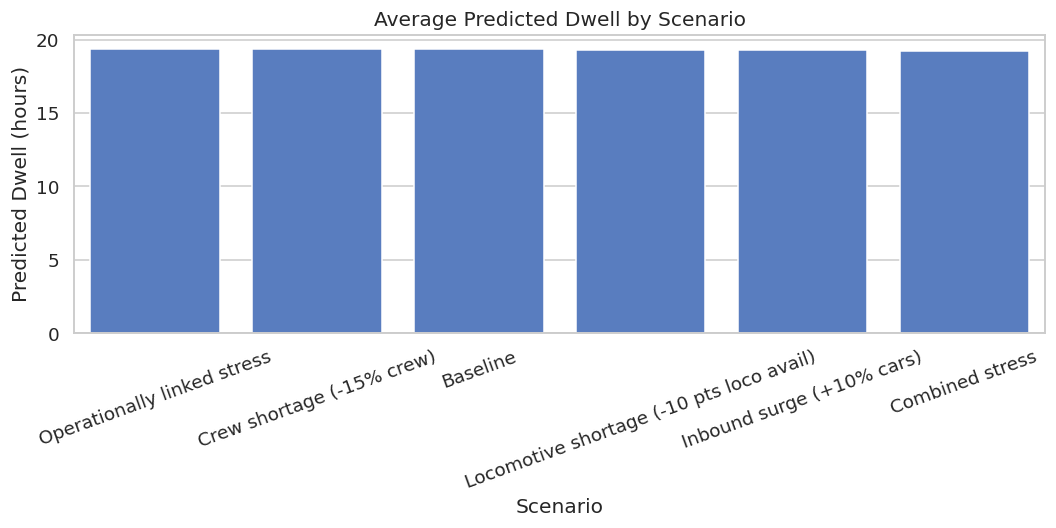

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(data=scenario_summary, x="scenario", y="avg_predicted_dwell")
plt.title("Average Predicted Dwell by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Predicted Dwell (hours)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Visualize terminal sensitivity under combined stress

This chart compares the increase in average predicted dwell by terminal under the combined-stress scenario. Larger values indicate terminals that appear more sensitive to simultaneous workload pressure and resource deterioration.

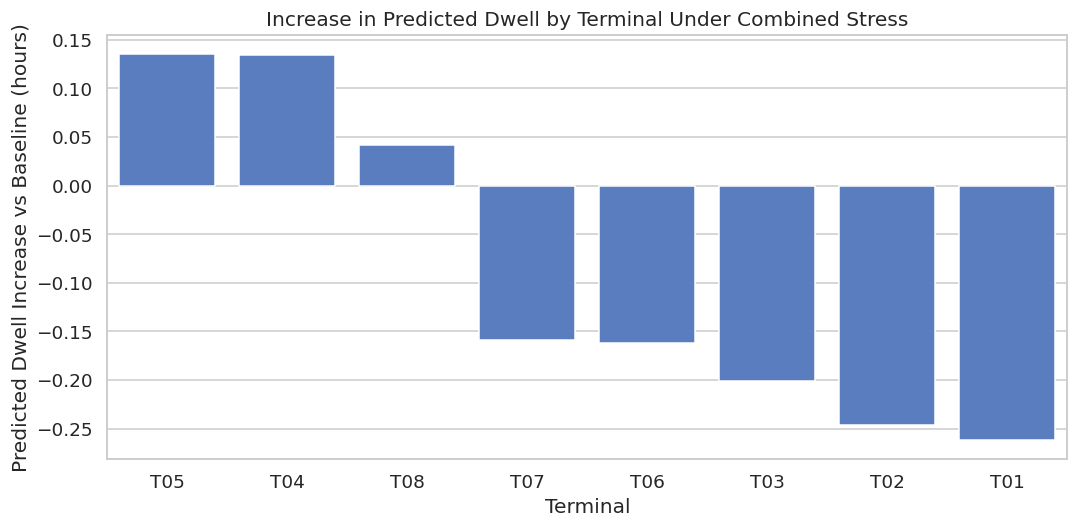

In [58]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=most_sensitive_terminals,
    x="terminal_id",
    y=combined_delta_col
)
plt.title("Increase in Predicted Dwell by Terminal Under Combined Stress")
plt.xlabel("Terminal")
plt.ylabel("Predicted Dwell Increase vs Baseline (hours)")
plt.tight_layout()
plt.show()

## Optional scenario detail: compare baseline vs combined stress by terminal

This table provides a compact side-by-side comparison of average predicted dwell at each terminal under baseline conditions and under combined stress. It can help support operational discussion about which terminals may warrant closer monitoring under adverse conditions.

In [59]:
terminal_compare = most_sensitive_terminals.copy()
terminal_compare = terminal_compare.rename(columns={
    "Baseline": "baseline_avg_predicted_dwell",
    "Combined stress": "combined_stress_avg_predicted_dwell",
    "Combined stress_delta": "combined_stress_increase"
})

terminal_compare

scenario,terminal_id,baseline_avg_predicted_dwell,combined_stress_avg_predicted_dwell,combined_stress_increase
0,T05,21.056,21.192,0.135
1,T04,23.305,23.439,0.134
2,T08,15.400,15.442,0.042
3,T07,17.075,16.916,-0.159
4,T06,16.423,16.261,-0.162
5,T03,22.202,22.000,-0.201
6,T02,18.570,18.324,-0.246
7,T01,20.745,20.483,-0.262


## Interpretation of scenario results

The upgraded scenario analysis produced two important findings.

First, the model still showed a **mixed directional response** under the simple isolated stress scenarios. Under the basic combined-stress setup, some terminals such as **T04** and **T05** showed higher predicted dwell, while others showed small declines relative to baseline. This reinforces an important limitation: the tuned Phase 1 LightGBM model is a predictive model, not a structural or causal simulator. When selected inputs are perturbed independently, the model may respond according to local patterns in the training data rather than a universal operational rule such as “less crew always increases dwell” or “higher inbound volume always worsens congestion.”

Second, the more **operationally linked stress** scenario produced the strongest threshold-breach signal. Using a 24-hour dwell warning threshold, the baseline breach rate was **2.46%**, while the linked-stress scenario increased that rate to **3.96%**. This is a more credible result than the isolated single-feature scenarios because the linked stress changes multiple correlated variables together — workload, yard-state, and resource capacity — in a more operationally coherent way.

Taken together, these results suggest that Notebook 06 is most useful as a **sensitivity and scenario-design experiment**. It shows that the model can support what-if analysis, but it also shows that scenario realism matters. Naive one-variable perturbations can create unrealistic combinations of inputs, while linked multi-variable stress scenarios produce outputs that are more interpretable and more aligned with the project’s operational warning objective.

## Conclusion

This notebook tested whether the tuned Phase 1 LightGBM model could be extended into a simple scenario-analysis workflow by applying controlled stress changes to test-period operating conditions.

The results showed that isolated single-feature perturbations do not always produce clean monotonic increases in predicted dwell across all terminals. That is an honest and important finding: a forecasting model trained on historical data should not automatically be treated as a causal simulator when inputs are changed independently.

At the same time, the notebook also showed that **scenario design quality matters**. The more operationally linked stress scenario produced the highest 24-hour dwell threshold-breach rate, increasing the share of flagged terminal-days from **2.46%** under baseline conditions to **3.96%**. This suggests that when workload, congestion, and resource variables are stressed together in a more coherent way, the model becomes more useful as an early-warning planning tool.

In that sense, Notebook 06 serves as a practical bridge from predictive modeling toward decision support. It demonstrates both the usefulness of scenario analysis and the need for disciplined, operationally realistic scenario construction in later phases.